<a href="https://colab.research.google.com/github/GiX007/image-analysis-and-processing/blob/main/pneumonia_detection_with_CNN_and_VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pneumonia Detection using Deep Learning

### Setup

In [1]:
# check GPU details
!nvidia-smi

# check available RAM
import psutil
ram_gb = psutil.virtual_memory().total / 1e9
print('\nYour runtime has {:.1f} GB of available RAM.'.format(ram_gb))

if ram_gb < 20:
    print('Not using a high-RAM runtime — consider upgrading for large experiments.\n')
else:
    print('Using a high-RAM runtime — good for large-scale processing!\n')

Thu Jul  3 22:12:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# essential imports
import os
import shutil
import copy
import glob
import joblib
from google.colab import files
import random
import time
from itertools import product

# data handling
import numpy as np
import pandas as pd
from collections import Counter

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

# image processing
from PIL import Image
import cv2

# progress bars
from tqdm.auto import tqdm

# scikit's library
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# pytorch for deep learning
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import torchvision
from torchvision.models import VGG16_Weights, ResNet18_Weights, Inception_V3_Weights, EfficientNet_B0_Weights
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset, Subset

# install and import torchinfo for model summaries
!pip install -q torchinfo
from torchinfo import summary

### Download the Dataset

In [3]:
# download the dataset from Kaggle using kagglehub
import kagglehub

# download latest version of the dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# print the path where the dataset has been saved
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


### Explore the Dataset

In [4]:
# define source and destination paths
source_base = os.path.join(path, "chest_xray")  # path is returned by kagglehub
destination_base = "data"

# create destination base if it doesn't exist
os.makedirs(destination_base, exist_ok=True)

# copy each split directory
for split in ["train", "val", "test"]:
  src_dir = os.path.join(source_base, split)
  dst_dir = os.path.join(destination_base, split)
  shutil.copytree(src_dir, dst_dir, dirs_exist_ok=True)  # dirs_exist_ok=True for overwriting if needed

# define path variables for easy access
data_dir = "data"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

In [5]:
# structure of the new data directory
print("The dataset folder is organized as follows:")
for dirpath, dirnames, filenames in os.walk(data_dir):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

The dataset folder is organized as follows:
There are 3 directories and 0 images in 'data'.
There are 2 directories and 0 images in 'data/train'.
There are 0 directories and 3875 images in 'data/train/PNEUMONIA'.
There are 0 directories and 1341 images in 'data/train/NORMAL'.
There are 2 directories and 0 images in 'data/val'.
There are 0 directories and 8 images in 'data/val/PNEUMONIA'.
There are 0 directories and 8 images in 'data/val/NORMAL'.
There are 2 directories and 0 images in 'data/test'.
There are 0 directories and 390 images in 'data/test/PNEUMONIA'.
There are 0 directories and 234 images in 'data/test/NORMAL'.


In [6]:
# rename val -> test_images: we will use them as test images to try the retrained models
os.rename(val_dir, "data/test_images")

In [7]:
# create new val folder in data/
os.makedirs("data/val")
os.makedirs("data/val/NORMAL")
os.makedirs("data/val/PNEUMONIA")

# move 10% of train set to newly created val set
for cls in ["NORMAL", "PNEUMONIA"]:
  src_dir = os.path.join(train_dir, cls)
  dst_dir = os.path.join("data/val", cls)

  images = os.listdir(src_dir)
  random.shuffle(images)

  num_val_images = int(0.1 * len(images))
  val_images = images[:num_val_images]

  for image in val_images:
    src_path = os.path.join(src_dir, image)
    dst_path = os.path.join(dst_dir, image)
    shutil.move(src_path, dst_path)

  print(f"Moved {num_val_images} images from {src_dir} to {dst_dir}.")

Moved 134 images from data/train/NORMAL to data/val/NORMAL.
Moved 387 images from data/train/PNEUMONIA to data/val/PNEUMONIA.


In [8]:
# function to plot data distribution in a given directory (train, val, test_images)
def plot_data_split(dir_path, title='Data Distribution'):
  """
  Plots the number of images per class (NORMAL=0, PNEUMONIA=1) in the given directory.

  Args:
      dir_path (str): Path to the directory (e.g., 'data/train')
      title (str): Title for the plot
  """
  normal_dir = os.path.join(dir_path, 'NORMAL')
  pneumonia_dir = os.path.join(dir_path, 'PNEUMONIA')

  normal_imgs = glob.glob(os.path.join(normal_dir, '*.jpeg'))
  pneumonia_imgs = glob.glob(os.path.join(pneumonia_dir, '*.jpeg'))

  data = [(img, 0) for img in normal_imgs] + [(img, 1) for img in pneumonia_imgs]
  df = pd.DataFrame(data, columns=['image', 'label'])
  df = df.sample(frac=1.0).reset_index(drop=True)

  counts = df['label'].value_counts().sort_index()
  print(f"\n{title} ({dir_path}):\n{counts}")

  plt.figure(figsize=(8, 6))
  sns.barplot(x=counts.index, y=counts.values)
  plt.title(title, fontsize=14)
  plt.xlabel('Class Label', fontsize=12)
  plt.ylabel('Image Count', fontsize=12)
  plt.xticks([0, 1], ['NORMAL (0)', 'PNEUMONIA (1)'])
  plt.tight_layout()
  plt.show()


Training Set Distribution (data/train):
label
0    1207
1    3488
Name: count, dtype: int64


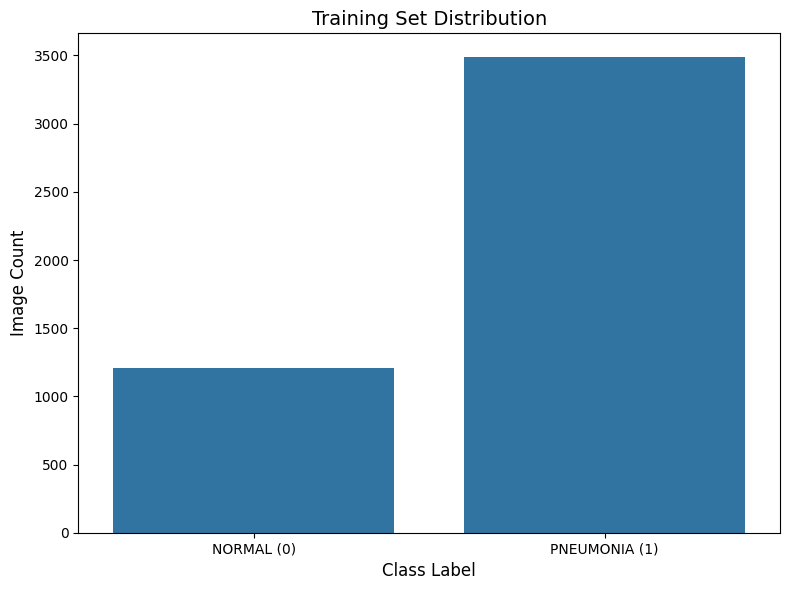

In [9]:
plot_data_split("data/train", title="Training Set Distribution")


Validation Set Distribution (data/val):
label
0    134
1    387
Name: count, dtype: int64


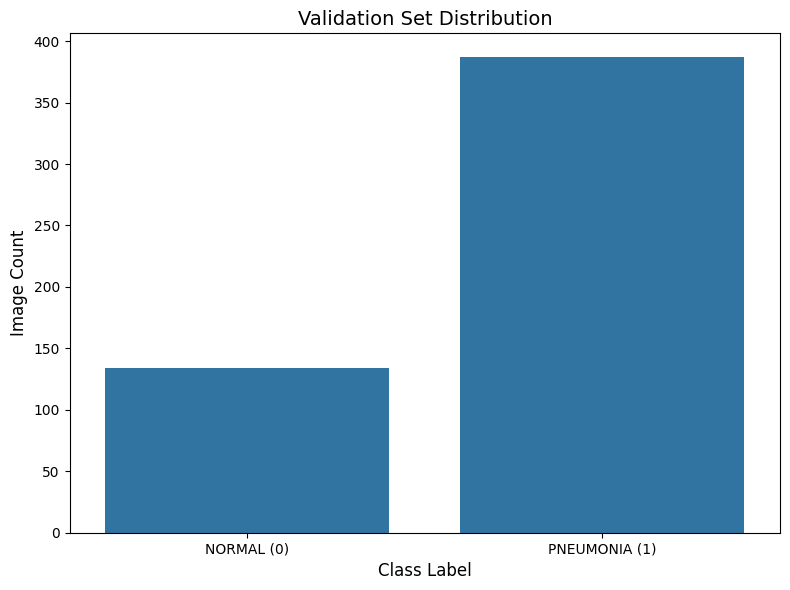

In [10]:
plot_data_split("data/val", title="Validation Set Distribution")


Test Set Distribution (data/test):
label
0    234
1    390
Name: count, dtype: int64


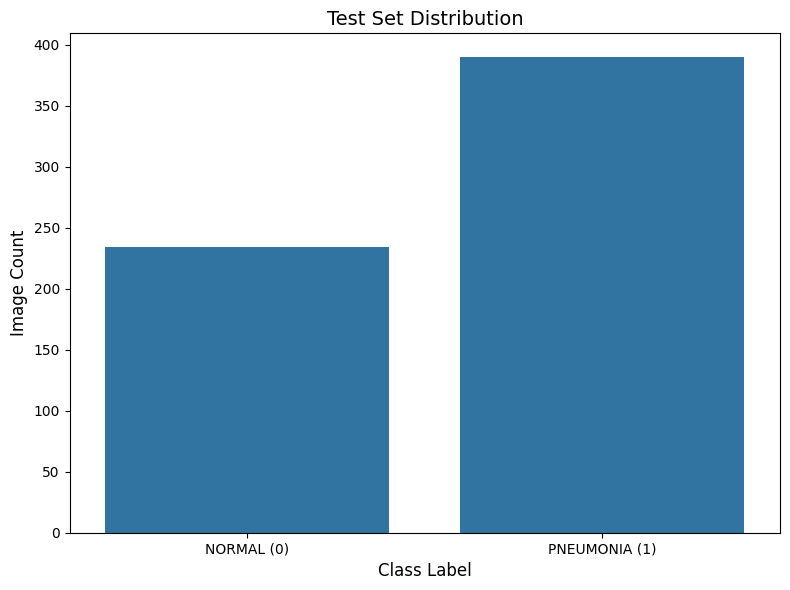

In [11]:
plot_data_split("data/test", title="Test Set Distribution")

In [12]:
# get the path to the normal and pneumonia sub-directories
normal_cases_dir = os.path.join(train_dir, 'NORMAL')
pneumonia_cases_dir = os.path.join(train_dir, 'PNEUMONIA')

# get the list of all the images
normal_cases = glob.glob(os.path.join(normal_cases_dir, '*.jpeg'))
pneumonia_cases = glob.glob(os.path.join(pneumonia_cases_dir, '*.jpeg'))

# an empty list. We will insert the data into this list in (img_path, label) format
train_data1 = []

# go through all the normal cases. The label for these cases will be 0
for img in normal_cases:
  train_data1.append((img,0))

# go through all the pneumonia cases. The label for these cases will be 1
for img in pneumonia_cases:
  train_data1.append((img, 1))

# get a pandas dataframe from the data we have in our list
train_data1 = pd.DataFrame(train_data1, columns=['image', 'label'],index=None)
train_data1.head(5)

,image,label
0,data/train/NORMAL/IM-0343-0001.jpeg,0
1,data/train/NORMAL/IM-0553-0001-0002.jpeg,0
2,data/train/NORMAL/NORMAL2-IM-0650-0001.jpeg,0
3,data/train/NORMAL/NORMAL2-IM-0699-0001.jpeg,0
4,data/train/NORMAL/NORMAL2-IM-0629-0001.jpeg,0


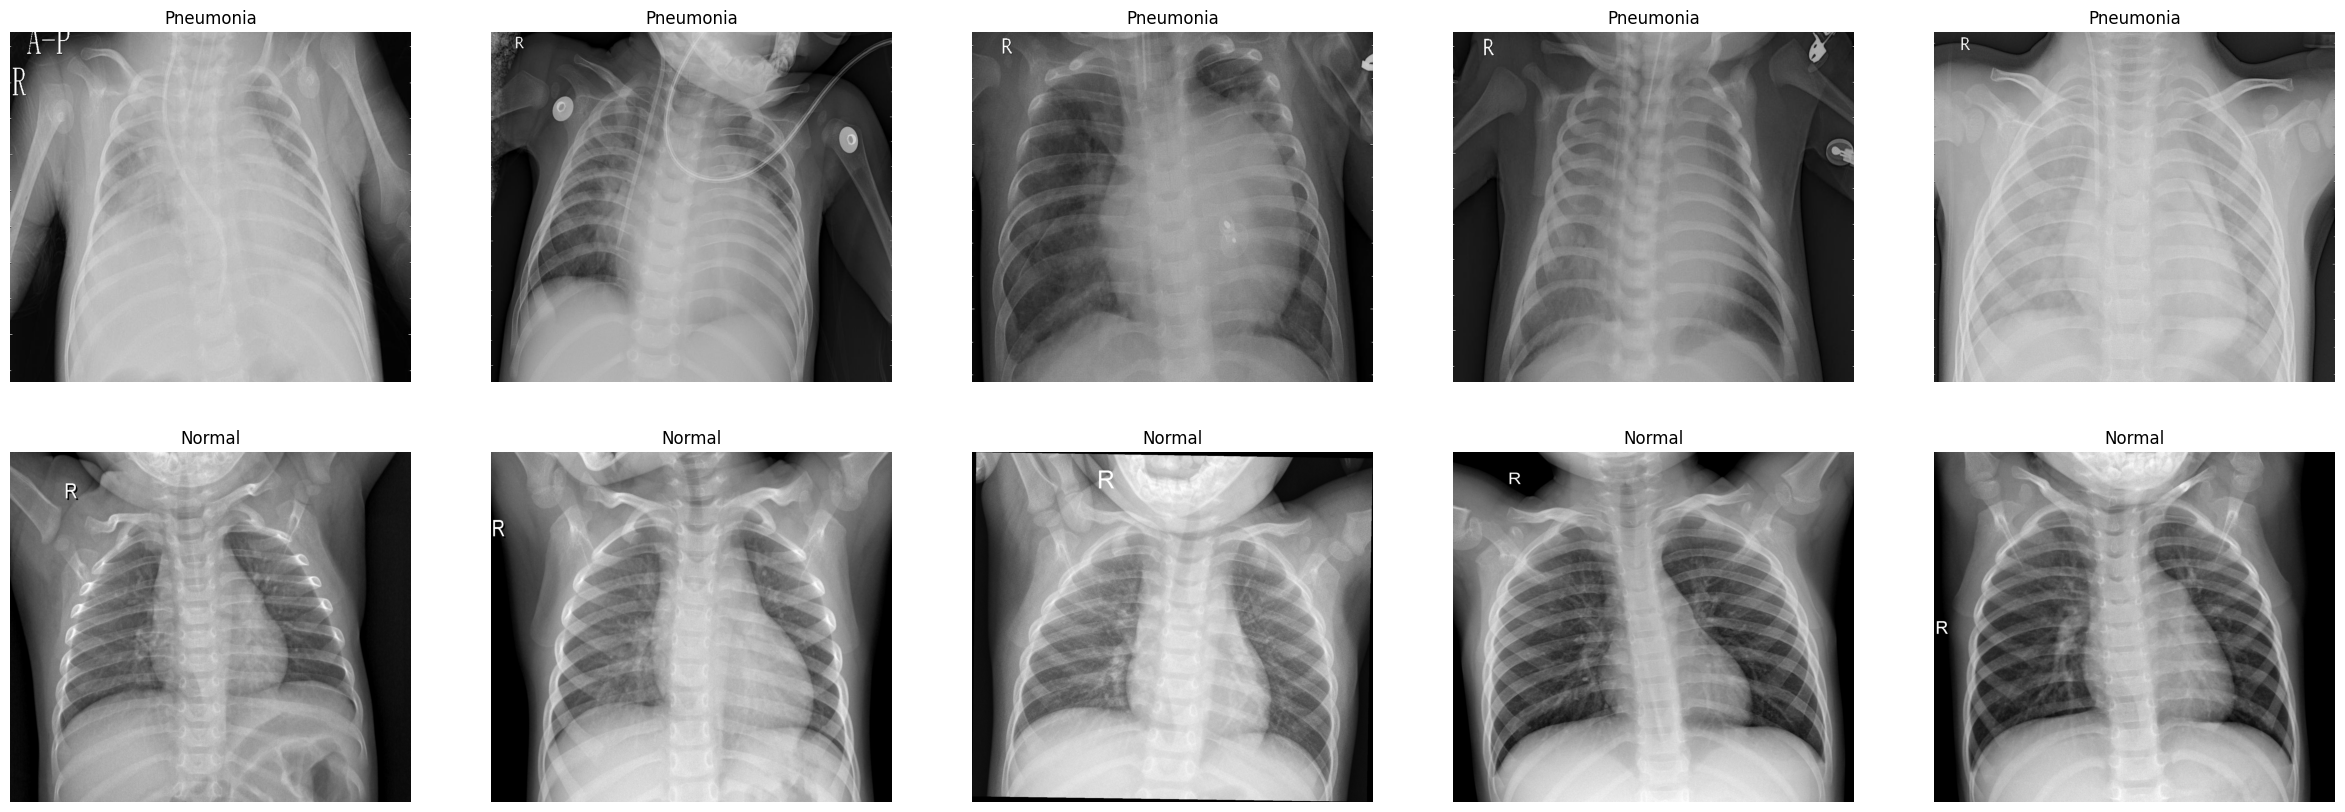

In [13]:
# get few samples for both the classes
pneumonia_samples = (train_data1[train_data1['label']==1]['image'].iloc[:5]).tolist()
normal_samples = (train_data1[train_data1['label']==0]['image'].iloc[:5]).tolist()

# concat the data in a single list and del the above two list
samples = pneumonia_samples + normal_samples
del pneumonia_samples, normal_samples

# plot the data
f, ax = plt.subplots(2,5, figsize=(30,10))
for i in range(10):
    img = cv2.imread(samples[i])
    ax[i//5, i%5].imshow(img, cmap='gray')
    if i<5:
        ax[i//5, i%5].set_title("Pneumonia")
    else:
        ax[i//5, i%5].set_title("Normal")
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_aspect('auto')
plt.show()

In [14]:
# select a random image and print its characteristics
img = random.choice(train_data1['image'])
print("Image path:", img)
print("Image shape:", cv2.imread(img).shape)
print("Image size:", os.path.getsize(img), "bytes")
print("Image type:", type(cv2.imread(img)))
print("Image data type:", cv2.imread(img).dtype)
print("Image max value:", cv2.imread(img).max())
print("Image min value:", cv2.imread(img).min())
print("Image mean value:", cv2.imread(img).mean())
print("Image standard deviation:", cv2.imread(img).std())
print("Image median value:", np.median(cv2.imread(img)))
print("\nImgage:\n", cv2.imread(img))

Image path: data/train/PNEUMONIA/person628_bacteria_2505.jpeg
Image shape: (1253, 1650, 3)
Image size: 200702 bytes
Image type: <class 'numpy.ndarray'>
Image data type: uint8
Image max value: 255
Image min value: 0
Image mean value: 114.61678831410676
Image standard deviation: 58.98871952066156
Image median value: 125.0

Imgage:
 [[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


In [15]:
# display how many images per class each folder in data has
for split in ["train", "val", "test"]:
  for cls in ["NORMAL", "PNEUMONIA"]:
    dir_path = os.path.join(data_dir, split, cls)
    print(f"There are {len(os.listdir(dir_path))} images in {dir_path}.")

There are 1207 images in data/train/NORMAL.
There are 3488 images in data/train/PNEUMONIA.
There are 134 images in data/val/NORMAL.
There are 387 images in data/val/PNEUMONIA.
There are 234 images in data/test/NORMAL.
There are 390 images in data/test/PNEUMONIA.


### Preprocess the Dataset

Create Datasets and Dataloaders.

In [16]:
BATCH_SIZE = 16
EPOCHS = 20

In [17]:
# define transforms (apply augmentation in train set)
train_transform = transforms.Compose([
    transforms.Resize((120, 120)), # resize to a common size
    transforms.Grayscale(num_output_channels=3),  # convert to 3-channel RGB
    transforms.RandomHorizontalFlip(p=0.5), # randomly flip images horizontally (50% chance)
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # small brightness & contrast jitter
    transforms.RandomRotation(degrees=10), # randomly rotate images by +- 10 degrees
    transforms.ToTensor(), # convert PIL to Tensor and scales to [0, 1]
])

val_test_transform = transforms.Compose([
    transforms.Resize((120, 120)), # resize to a common size
    transforms.Grayscale(num_output_channels=3),  # convert to 3-channel RGB
    transforms.ToTensor(), # convert PIL to Tensor and scales to [0, 1]
])

# load datasets
train_dataset = datasets.ImageFolder(root="data/train", transform=train_transform)
val_dataset = datasets.ImageFolder(root="data/val", transform=val_test_transform)
test_dataset = datasets.ImageFolder(root="data/test", transform=val_test_transform)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Calculate class weights.

In [18]:
# get targets from the training dataset
targets = [label for _, label in train_dataset.samples]
class_counts = Counter(targets)

# total samples / class count = weight
total = sum(class_counts.values())
class_weights = [total / class_counts[i] for i in range(len(class_counts))]

# convert to Tensor for use in loss
class_weights_tensor = torch.FloatTensor(class_weights)
print("Class weights:", class_weights_tensor)

Class weights: tensor([3.8898, 1.3460])


Define some helper functions.

In [19]:
# helper functions

def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=34, patience=5):
  """
  Trains a PyTorch model using either a custom NN or a pretrained model.

  Args:
      model (torch.nn.Module): A PyTorch model to train.
      dataloaders (dict): A dictionary containing the training and validation dataloaders.
      criterion (torch.nn.Module): A PyTorch loss function to minimize.
      optimizer (torch.optim): A PyTorch optimizer to use for training.
      device (str): The device to train the model on ('cuda' or 'cpu').
      num_epochs (int): The number of epochs to train for.
      patience (int): The number of epochs to wait for improvement before early stopping.
  """
  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0
  val_loss_min = np.inf
  early_stop_counter = 0

  # logging dict
  history = {
      'train_loss': [],
      'train_acc': [],
      'val_loss': [],
      'val_acc': []
  }

  for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    epoch_metrics = {}

    for phase in ['train', 'val']:
      if phase == 'train':
        model.train()
      else:
        model.eval()

      running_loss = 0.0
      running_corrects = 0

      for inputs, labels in dataloaders[phase]:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == 'train'):
          outputs = model(inputs)
          _, preds = torch.max(outputs, 1)
          loss = criterion(outputs, labels)

          if phase == 'train':
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

      epoch_loss = running_loss / len(dataloaders[phase].dataset)
      epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

      epoch_metrics[f'{phase}_loss'] = epoch_loss
      epoch_metrics[f'{phase}_acc'] = epoch_acc.item()  # convert to float

      history[f'{phase}_loss'].append(epoch_loss)
      history[f'{phase}_acc'].append(epoch_acc.item())  # convert to float

      print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

      # save best model
      if phase == 'val':
        if epoch_loss < val_loss_min:
          val_loss_min = epoch_loss
          best_model_wts = copy.deepcopy(model.state_dict())
          early_stop_counter = 0
        else:
          early_stop_counter += 1
          if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_model_wts)
            return model, history

  # epoch summary
  print(f"\nTrain Loss: {epoch_metrics['train_loss']:.4f} | Train Acc: {epoch_metrics['train_acc']:.4f} | Val Loss: {epoch_metrics['val_loss']:.4f} | Val Acc: {epoch_metrics['val_acc']:.4f}")


  model.load_state_dict(best_model_wts)
  return model, history


def plot_training_curves(history):
  """
  Plots loss and accuracy curves from training history.

  Args:
      history (dict): Dictionary with keys 'train_loss', 'val_loss', 'train_acc', 'val_acc'
  """
  epochs = range(1, len(history['train_loss']) + 1)

  plt.figure(figsize=(14, 5))

  # plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history['train_loss'], label='Train Loss')
  plt.plot(epochs, history['val_loss'], label='Val Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss Curve')
  plt.legend()

  # plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, history['train_acc'], label='Train Acc')
  plt.plot(epochs, history['val_acc'], label='Val Acc')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Accuracy Curve')
  plt.legend()

  plt.tight_layout()
  plt.show()


def evaluate_model_on_test(model, test_loader, device):
  """
  Evaluates a PyTorch model on the test set.

  Args:
      model (torch.nn.Module): A PyTorch model to evaluate.
      test_loader (torch.utils.data.DataLoader): A DataLoader for the test set.
      device (str): The device to evaluate the model on ('cuda' or 'cpu').
  """
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  # compute metrics
  acc  = accuracy_score(all_labels, all_preds)
  prec = precision_score(all_labels, all_preds, average='binary')
  rec  = recall_score(all_labels, all_preds, average='binary')
  f1   = f1_score(all_labels, all_preds, average='binary')
  report = classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia'])
  cm = confusion_matrix(all_labels, all_preds)

  # print results
  print("=== Test Evaluation ===")
  print(f"Accuracy : {acc:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"Recall   : {rec:.4f}")
  print(f"F1 Score : {f1:.4f}")
  print("\nClassification Report:\n", report)
  print("Confusion Matrix:\n", cm)

  # plot cm
  plt.figure(figsize=(6, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.title('Confusion Matrix')
  plt.show()

  return {
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "f1_score": f1,
      "confusion_matrix": cm,
      "classification_report": report
  }


def predict_on_image(image_path, model, device, class_names=['NORMAL', 'PNEUMONIA'], transform=val_test_transform):
  """
  Predicts the class of an image using a PyTorch model.

  Args:
      image_path (str): Path to the image file.
      model (torch.nn.Module): A PyTorch model to use for inference.
      device (str): The device to use for inference ('cuda' or 'cpu').
      class_names (list): List of class names.
      transform (callable): A transformation to apply to the image before inference.
  """

  # load and preprocess image (same transform as val_test_transform)
  img = Image.open(image_path)
  img_tensor = transform(img).unsqueeze(0).to(device)

  # model prediction
  model.eval()
  with torch.no_grad():
    outputs = model(img_tensor)
    probs = F.softmax(outputs, dim=1)
    prob, pred = torch.max(probs, 1)

  predicted_label = class_names[pred.item()]
  true_label = os.path.basename(os.path.dirname(image_path)).upper()

  # print prediction
  print(f"True Label: {true_label}")
  print(f"Predicted Label: {predicted_label}")
  print(f"Probability: {prob.item():.4f}\n")

  # plot ===
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"True: {true_label} | Predicted: {predicted_label} ({prob.item():.2f})", fontsize=12)
  plt.show()


def get_random_image_from_test_images():
  """
  Returns a random image path from the test_images folder.
  """
  base_dir = 'data/test_images'
  classes = ['NORMAL', 'PNEUMONIA']

  # pick a random class subfolder
  selected_class = random.choice(classes)
  class_folder = os.path.join(base_dir, selected_class)

  # get list of .jpeg images
  images = [os.path.join(class_folder, f)
            for f in os.listdir(class_folder)
            if f.lower().endswith('.jpeg')]

  # pick one random image
  image_path = random.choice(images)
  return image_path

### Custom CNN

In [22]:
class custom_CNN(nn.Module):
  def __init__(self, num_classes=2):
    super(custom_CNN, self).__init__()

    # block 1
    self.block1 = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(2),
        nn.Dropout(0.25)
        )

    # block 2
    self.block2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(2),
        nn.Dropout(0.25)
        )

    # block 3
    self.block3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(2),
        nn.Dropout(0.25)
        )

    # fully connected layers
    self.fc1 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 15 * 15, 256),  # input
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(0.5)
        )

    self.fc2 = nn.Linear(256, num_classes)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.fc1(x)
    return self.fc2(x)  # logits

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"

custom_CNN_model = custom_CNN(num_classes=2)
custom_CNN_model = custom_CNN_model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(custom_CNN_model.parameters(), lr=1e-4) #, weight_decay=0.0005

dataloaders = {"train": train_loader, "val": val_loader}

custom_CNN_model, cnn_history = train_model(custom_CNN_model, dataloaders, criterion, optimizer, device, num_epochs=EPOCHS)


Epoch 1/20
Train Loss: 0.2983 Acc: 0.8496
Val Loss: 0.2229 Acc: 0.9386

Epoch 2/20
Train Loss: 0.2310 Acc: 0.9044
Val Loss: 0.4052 Acc: 0.8944

Epoch 3/20
Train Loss: 0.1858 Acc: 0.9280
Val Loss: 0.2072 Acc: 0.9347

Epoch 4/20
Train Loss: 0.1578 Acc: 0.9410
Val Loss: 0.1242 Acc: 0.9578

Epoch 5/20
Train Loss: 0.1375 Acc: 0.9510
Val Loss: 0.1153 Acc: 0.9520

Epoch 6/20
Train Loss: 0.1288 Acc: 0.9580
Val Loss: 0.5788 Acc: 0.9213

Epoch 7/20
Train Loss: 0.1371 Acc: 0.9534
Val Loss: 0.1315 Acc: 0.9443

Epoch 8/20
Train Loss: 0.1311 Acc: 0.9521
Val Loss: 0.1458 Acc: 0.9578

Epoch 9/20
Train Loss: 0.1295 Acc: 0.9527
Val Loss: 0.5964 Acc: 0.8752

Epoch 10/20
Train Loss: 0.1368 Acc: 0.9519
Val Loss: 0.1517 Acc: 0.9482
Early stopping at epoch 10


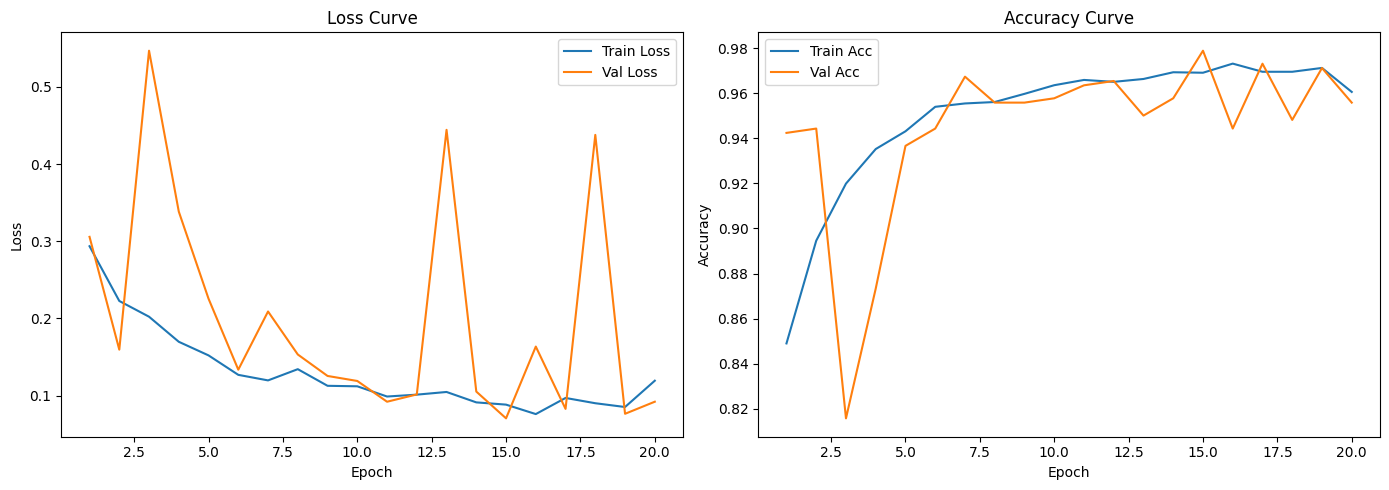

In [24]:
# plot learning curves
plot_training_curves(cnn_history)

=== Test Evaluation ===
Accuracy : 0.8093
Precision: 0.7673
Recall   : 0.9974
F1 Score : 0.8673

Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.50      0.66       234
   Pneumonia       0.77      1.00      0.87       390

    accuracy                           0.81       624
   macro avg       0.88      0.75      0.76       624
weighted avg       0.85      0.81      0.79       624

Confusion Matrix:
 [[116 118]
 [  1 389]]


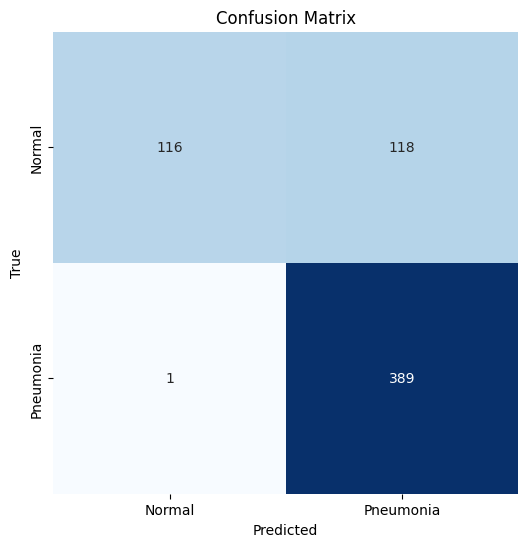

In [25]:
# evaluate the custom cnn model on the test set
results = evaluate_model_on_test(custom_CNN_model, test_loader, device)

True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Probability: 0.8917



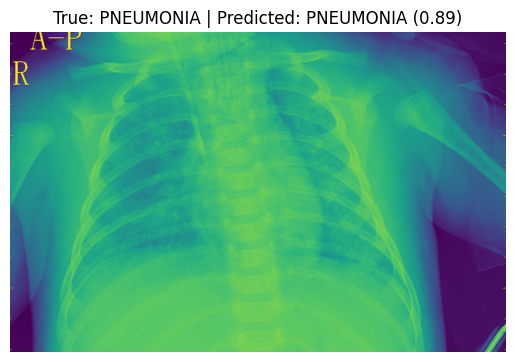

In [26]:
# make an inference on a random selected image from data/test_images
img_path = get_random_image_from_test_images()
predict_on_image(img_path, custom_CNN_model, device)

In [27]:
# save and download the model
torch.save(custom_CNN_model.state_dict(), "custom_CNN_model.pth")
files.download("custom_CNN_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### VGG16

In [30]:
# load vgg16
vgg16_model = torchvision.models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

for param in vgg16_model.parameters():
  param.requires_grad = False # freeze all layers

# replace only the final layer in the classifier
num_ftrs = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Linear(in_features=num_ftrs, out_features=2, bias=True)

In [ ]:
nn.Sequential(
      nn.BatchNorm1d(in_features),
      nn.Dropout(dropout),
      nn.Linear(in_features, hidden_size),
      nn.ReLU(),
      nn.Linear(hidden_size, num_classes)
      )

In [31]:
# Move model to device
vgg16_model = vgg16_model.to(device)

# Define loss with class weights for imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

# Only train the classifier layer
optimizer = torch.optim.Adam(vgg16_model.classifier.parameters(), lr=1e-4)

# Train the model using existing function
vgg16_model, vgg_history = train_model(vgg16_model, dataloaders, criterion, optimizer, device, num_epochs=EPOCHS)


Epoch 1/20
Train Loss: 0.4502 Acc: 0.7951
Val Loss: 0.4795 Acc: 0.7697

Epoch 2/20
Train Loss: 0.3149 Acc: 0.8780
Val Loss: 0.4255 Acc: 0.8100

Epoch 3/20
Train Loss: 0.2785 Acc: 0.8863
Val Loss: 0.3928 Acc: 0.8253

Epoch 4/20
Train Loss: 0.2648 Acc: 0.8912
Val Loss: 0.3959 Acc: 0.8234

Epoch 5/20
Train Loss: 0.2459 Acc: 0.8999
Val Loss: 0.3394 Acc: 0.8522

Epoch 6/20
Train Loss: 0.2470 Acc: 0.8971
Val Loss: 0.3455 Acc: 0.8484

Epoch 7/20
Train Loss: 0.2365 Acc: 0.9016
Val Loss: 0.3146 Acc: 0.8618

Epoch 8/20
Train Loss: 0.2431 Acc: 0.8993
Val Loss: 0.3290 Acc: 0.8560

Epoch 9/20
Train Loss: 0.2285 Acc: 0.9044
Val Loss: 0.2723 Acc: 0.8925

Epoch 10/20
Train Loss: 0.2379 Acc: 0.8986
Val Loss: 0.3187 Acc: 0.8580

Epoch 11/20
Train Loss: 0.2322 Acc: 0.9078
Val Loss: 0.2997 Acc: 0.8695

Epoch 12/20
Train Loss: 0.2335 Acc: 0.9065
Val Loss: 0.2826 Acc: 0.8733

Epoch 13/20
Train Loss: 0.2172 Acc: 0.9095
Val Loss: 0.3508 Acc: 0.8484

Epoch 14/20
Train Loss: 0.2224 Acc: 0.9052
Val Loss: 0.2860

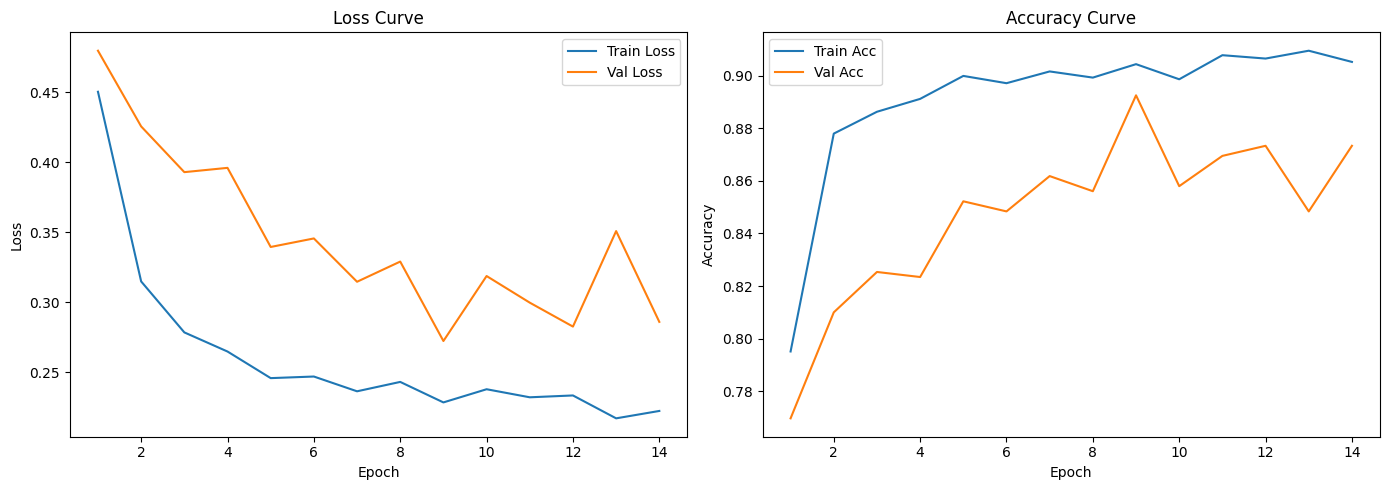

In [32]:
# plot learning curves
plot_training_curves(vgg_history)

=== Test Evaluation ===
Accuracy : 0.8494
Precision: 0.8379
Recall   : 0.9410
F1 Score : 0.8865

Classification Report:
               precision    recall  f1-score   support

      Normal       0.88      0.70      0.78       234
   Pneumonia       0.84      0.94      0.89       390

    accuracy                           0.85       624
   macro avg       0.86      0.82      0.83       624
weighted avg       0.85      0.85      0.85       624

Confusion Matrix:
 [[163  71]
 [ 23 367]]


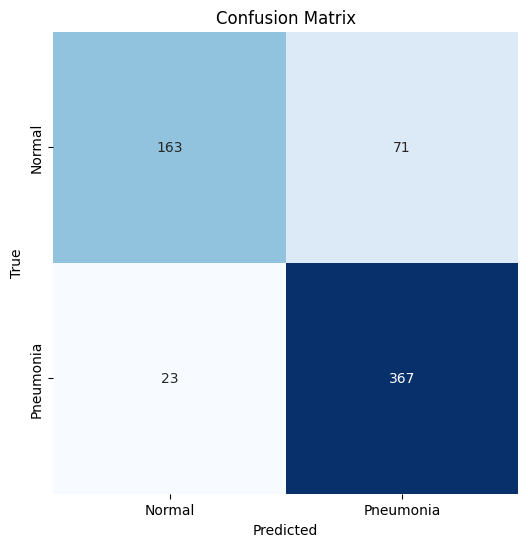

In [33]:
# evaluate vgg16 on the test set
results = evaluate_model_on_test(vgg16_model, test_loader, device)

True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Probability: 0.8966



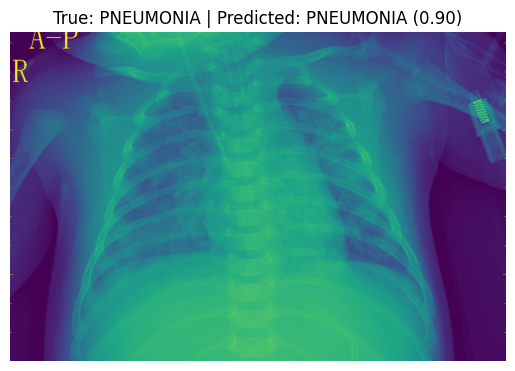

In [34]:
# make an inference on a random selected image from data/test_images
image_path = get_random_image_from_test_images()
predict_on_image(image_path, vgg16_model, device)

In [35]:
# save and download the model
torch.save(vgg16_model.state_dict(), "vgg16_model.pth")
files.download("vgg16_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>